# LSTM from scratch

Building a Long Short-Term Memory network from the ground up in PyTorch — the gates, the cell state, the backprop — then training it on daily gold prices. Follows the style of `micrograd/lecture.ipynb` and `nanoGPT/gpt-dev.ipynb`.

In [28]:
import csv
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1337)

In [30]:
# daily gold prices (GC=F futures, in USD), 5 years of trading days
# downloaded once from yahoo finance and saved to gold.csv, so this notebook runs offline
with open('gold.csv') as f:
    rows = list(csv.DictReader(f))

dates = [r['Date'] for r in rows]
prices = torch.tensor([float(r['Close']) for r in rows], dtype=torch.float32)
print(len(prices), 'trading days')
print('first:', dates[0], prices[0].item(), '| last:', dates[-1], prices[-1].item())
print(rows[:2])

1257 trading days
first: 2021-07-20 1810.9000244140625 | last: 2026-07-20 4027.199951171875
[{'Date': '2021-07-20', 'Close': '1810.9'}, {'Date': '2021-07-21', 'Close': '1802.9'}]


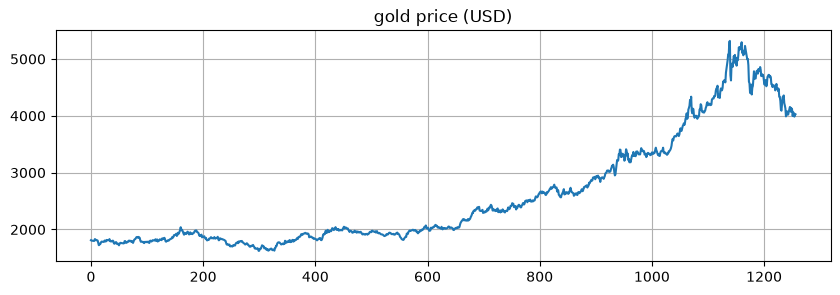

In [3]:
# the 2021-2026 gold run: a strong, wandering uptrend
plt.figure(figsize=(10, 3))
plt.plot(prices)
plt.grid()
plt.title('gold price (USD)');

In [4]:
# raw prices wander all over the place - neural nets like stationary inputs.
# so we model the daily log returns instead: r[t] = log p[t+1] - log p[t]
# (we can always integrate the predicted returns back into a price path later)
rets = torch.log(prices[1:]) - torch.log(prices[:-1])

# normalize using the TRAIN split statistics only - the future is not allowed to leak into the past
n = int(0.9 * len(rets))
mean, std = rets[:n].mean(), rets[:n].std()
data = (rets - mean) / std

# and we split by TIME, not randomly: the first 90% is the past, the last 10% is the future
train_data = data[:n]
val_data = data[n:]
print(f'{len(train_data)} train days, {len(val_data)} val days')
print(f'train mean {mean.item():.6f}, train std {std.item():.6f}')

1130 train days, 126 val days
train mean 0.000828, train std 0.010148


In [1]:
# notice: the returns are roughly mean-zero noise, and the "volatility" comes in clusters
# (the val period at the end is a much wilder regime than most of the train period)
plt.figure(figsize=(10, 3))
plt.plot(data)
plt.axvline(len(train_data), color='r', linestyle='--')
plt.grid()
plt.title('daily log returns (normalized)');

NameError: name 'plt' is not defined

In [6]:
# the task: given the last block_size returns, predict the next one
# one chunk of 8 consecutive days gives us 8 training examples, with context growing from 1 to 8
block_size = 8
x = train_data[:block_size]
y = train_data[1:block_size + 1]
for t in range(block_size):
    context = x[:t + 1]
    target = y[t]
    print(f'when input is {[round(v, 2) for v in context.tolist()]} the target: {target:.2f}')

when input is [-0.52] the target: 0.03
when input is [-0.52, 0.03] the target: -0.28
when input is [-0.52, 0.03, -0.28] the target: -0.23
when input is [-0.52, 0.03, -0.28, -0.23] the target: -0.04
when input is [-0.52, 0.03, -0.28, -0.23, -0.04] the target: -0.08
when input is [-0.52, 0.03, -0.28, -0.23, -0.04, -0.08] the target: 1.64
when input is [-0.52, 0.03, -0.28, -0.23, -0.04, -0.08, 1.64] the target: -1.09
when input is [-0.52, 0.03, -0.28, -0.23, -0.04, -0.08, 1.64, -1.09] the target: 0.22


In [7]:
# hyperparameters for the data loader
block_size = 64 # how many days of history does the model get to see?
batch_size = 32 # how many independent windows will we process in parallel?
# ------------

def get_batch(split):
    # sample a random batch of windows from a split
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix]).unsqueeze(-1)        # (B, T, 1)
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix]).unsqueeze(-1) # (B, T, 1)
    return x, y

xb, yb = get_batch('train')
print('inputs:', xb.shape)  # (B, T, C) = (batch, time, channels)
print('targets:', yb.shape) # shifted one day into the future
# note C=1: each timestep is a single scalar. there is no embedding table here -
# our "tokens" are continuous numbers, so the recurrence itself has to do all the work

inputs: torch.Size([32, 64, 1])
targets: torch.Size([32, 64, 1])


In [8]:
# a baseline to beat: the "do nothing" forecaster, which always predicts 0 (= no change tomorrow)
# any model that can't beat this is useless
eval_iters = 50
baseline = {}
for split in ['train', 'val']:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        X, Y = get_batch(split)
        losses[k] = (Y ** 2).mean() # mse of predicting all zeros
    baseline[split] = losses.mean()
    print(f'do-nothing baseline {split} loss: {losses.mean():.4f}')

do-nothing baseline train loss: 0.9946
do-nothing baseline val loss: 3.4963


### The mathematical trick in recurrence: the hidden state

Before the LSTM, let's build the thing it fixed. A vanilla RNN keeps a hidden state `h` that gets overwritten every timestep by squashing the past and the present through a `tanh`:

`h_t = tanh(Wx @ x_t + Wh @ h_{t-1} + b)`

In [9]:
# version 1: an explicit loop over time, with raw tensors. consider the following toy example
torch.manual_seed(1337)
B, T, H = 1, 5, 3

Wx = torch.randn(1, H) * 0.1  # input -> hidden
Wh = torch.randn(H, H) * 0.1  # hidden -> hidden
b = torch.zeros(H)

h = torch.zeros(B, H)             # the hidden state starts at zero
x = torch.randn(B, T, 1)          # a toy sequence of 5 scalars
for t in range(T):
    h = torch.tanh(x[:, t, :] @ Wx + h @ Wh + b) # (B,1)@(1,H) + (B,H)@(H,H) -> (B,H)
    print(f't={t}: h = {[round(v, 3) for v in h[0].tolist()]}')
# h is the entire memory of the network - a single vector, re-written every step

t=0: h = [-0.127, -0.129, -0.076]
t=1: h = [-0.1, -0.108, -0.084]
t=2: h = [0.02, 0.013, -0.009]
t=3: h = [0.034, 0.033, 0.023]
t=4: h = [0.238, 0.245, 0.15]


In [10]:
# version 2: as modules we can reuse
class RNNCell(nn.Module):
    """ a single vanilla RNN timestep: h_t = tanh(Wx x_t + Wh h_{t-1} + b) """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wx = nn.Linear(input_size, hidden_size)
        self.Wh = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        return torch.tanh(self.Wx(x) + self.Wh(h))


class RNN(nn.Module):
    """ a vanilla RNN unrolled over a sequence """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = RNNCell(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, hx=None):
        B, T, _ = x.shape
        h = x.new_zeros(B, self.hidden_size) if hx is None else hx
        outs = []
        for t in range(T):
            h = self.cell(x[:, t, :], h)   # (B, 1) -> (B, H)
            outs.append(h)
        return torch.stack(outs, dim=1), h  # (B, T, H)

In [39]:
# so what's wrong with it? let's watch the gradient flow backwards through time.
# setup: a 50-step sequence that is all zeros except a single spike at t=0,
# and a loss that only pulls on the LAST hidden state. for the rnn to use the
# spike, the gradient of that loss has to survive 50 steps of backprop.
torch.manual_seed(1337)
rnn_cell = RNNCell(1, 16)

x = torch.zeros(1, 50, 1); x[0, 0, 0] = 1.0
h = torch.zeros(1, 16)
hs = []
for t in range(50):
    h = rnn_cell(x[:, t, :], h)
    h.retain_grad() # so we can inspect the gradient at every t
    hs.append(h)
hs[-1].square().sum().backward()

grads_rnn = [hs[t].grad.norm().item() for t in range(50)]
print('||dL/dh_t|| at t =', [0, 10, 20, 30, 40, 49])
print([f'{grads_rnn[t]:.2e}' for t in [0, 10, 20, 30, 40, 49]])
# the gradient DIES going backwards: every step multiplies it by Wh and by the
# tanh derivative (at most 1), so a few dozen steps back there is simply nothing left.
# the rnn cannot learn from the distant past. remember this number - we will be back.

||dL/dh_t|| at t = [0, 10, 20, 30, 40, 49]
['3.16e-17', '9.40e-14', '2.67e-10', '8.39e-07', '2.08e-03', '4.12e+00']


### The mathematical trick in the LSTM: the cell state

The LSTM (Hochreiter & Schmidhuber, 1997) gives the network a second state `c` - the **cell state** - that is updated by *addition*, not by repeated squashing:

`c_t = f * c_{t-1} + i * g`

Because the derivative of a sum does not multiply anything together, the gradient can flow backwards through time along `c` without decaying - an additive "gradient highway". What gets written into, kept in, and read out of the highway is controlled by three **gates** - vectors of soft, differentiable if-statements in (0, 1):

- `f` (forget gate): how much of the old memory to keep
- `i` (input gate): how much of the new candidate `g` to write
- `o` (output gate): how much of the memory to expose as the hidden state `h_t = o * tanh(c_t)`

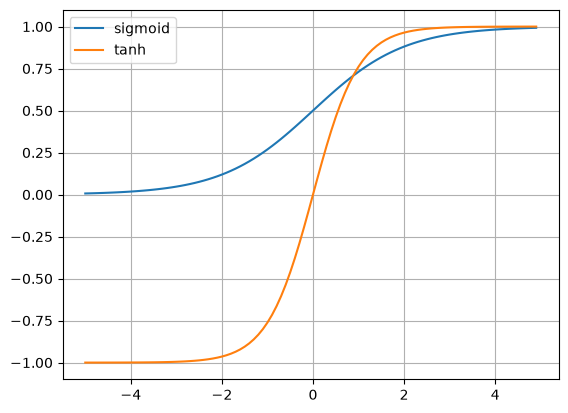

In [12]:
# the two nonlinearities we need:
# sigmoid squishes to (0, 1)  -> a soft switch, perfect for gates
# tanh squishes to (-1, 1)    -> signed content, perfect for the candidate and the readout
xs = np.arange(-5, 5, 0.1)
plt.plot(xs, 1 / (1 + np.exp(-xs)), label='sigmoid')
plt.plot(xs, np.tanh(xs), label='tanh')
plt.grid(); plt.legend();

In [13]:
# the four gates, computed in one shot and then chunked apart. toy example:
torch.manual_seed(1337)
B, C_in, H = 4, 1, 8

x = torch.randn(B, C_in)   # today's input: (B, C_in)
h = torch.randn(B, H)      # yesterday's hidden state: (B, H)
c = torch.randn(B, H)      # yesterday's cell state: (B, H)

# one big matrix multiply produces all four gates at once: 4*H numbers per example
W_ih = torch.randn(4 * H, C_in) * 0.1 # input -> gates
W_hh = torch.randn(4 * H, H) * 0.1    # hidden -> gates
b_ih = torch.zeros(4 * H)
b_hh = torch.zeros(4 * H)

gates = x @ W_ih.T + b_ih + h @ W_hh.T + b_hh  # (B, 4H)
i, f, g, o = gates.chunk(4, dim=1)             # 4 x (B, H) - this is PyTorch's gate order: i, f, g, o

i = torch.sigmoid(i)  # input gate:  how much of the candidate to write
f = torch.sigmoid(f)  # forget gate: how much of the old memory to keep
g = torch.tanh(g)     # candidate:   the new content itself, in (-1, 1)
o = torch.sigmoid(o)  # output gate: how much of the memory to expose

c = f * c + i * g     # the highway: the cell state is updated by ADDITION
h = o * torch.tanh(c) # the hidden state is a gated, squashed readout of the cell

print('gates:', gates.shape, '| new c:', c.shape, '| new h:', h.shape)

gates: torch.Size([4, 32]) | new c: torch.Size([4, 8]) | new h: torch.Size([4, 8])


In [14]:
# the same thing as a module we can train
class LSTMCell(nn.Module):
    """ a single LSTM timestep, from scratch """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        k = 1.0 / math.sqrt(hidden_size) # same init pytorch uses for nn.LSTM
        self.weight_ih = nn.Parameter(torch.empty(4 * hidden_size, input_size).uniform_(-k, k))
        self.weight_hh = nn.Parameter(torch.empty(4 * hidden_size, hidden_size).uniform_(-k, k))
        self.bias_ih = nn.Parameter(torch.zeros(4 * hidden_size))
        self.bias_hh = nn.Parameter(torch.zeros(4 * hidden_size))

    def forward(self, x, hx):
        h, c = hx                                                    # both (B, H)
        gates = x @ self.weight_ih.T + self.bias_ih + h @ self.weight_hh.T + self.bias_hh # (B, 4H)
        i, f, g, o = gates.chunk(4, dim=1)                           # gate order: i, f, g, o
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

### Sanity check: bit-exact against torch.nn

Same pattern as the micrograd lecture: transliterate our scratch implementation into PyTorch's, with identical weights, in double precision - and verify the numbers agree. PyTorch's `nn.LSTMCell` has exactly the same four parameters we wrote (`weight_ih, weight_hh, bias_ih, bias_hh`), and its gate order is `(i, f, g, o)` - which is why we chunked in that order.

In [40]:
# our LSTMCell vs torch.nn.LSTMCell, one timestep
ref = nn.LSTMCell(3, 5).double()
mine = LSTMCell(3, 5).double()

with torch.no_grad(): # copy pytorch's weights into our cell, so both see identical numbers
    for p_mine, p_ref in zip(mine.parameters(), ref.parameters()):
        p_mine.copy_(p_ref)

torch.manual_seed(1337)
x = torch.randn(4, 3, dtype=torch.float64)
h0 = torch.randn(4, 5, dtype=torch.float64)
c0 = torch.randn(4, 5, dtype=torch.float64)

h_ref, c_ref = ref(x, (h0, c0))
h_mine, c_mine = mine(x, (h0, c0))

print('h matches:', torch.allclose(h_mine, h_ref), '| max diff:', (h_mine - h_ref).abs().max().item())
print('c matches:', torch.allclose(c_mine, c_ref), '| max diff:', (c_mine - c_ref).abs().max().item())

h matches: True | max diff: 2.7755575615628914e-17
c matches: True | max diff: 1.1102230246251565e-16


In [41]:
# now unroll the cell over a whole sequence
class LSTM(nn.Module):
    """ an LSTM unrolled over a sequence, from scratch """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = LSTMCell(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, hx=None):
        B, T, _ = x.shape
        if hx is None:
            h = x.new_zeros(B, self.hidden_size)  # (B, H)
            c = x.new_zeros(B, self.hidden_size)  # (B, H)
        else:
            h, c = hx
        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], (h, c))  # feed one timestep, get the next state
            outs.append(h)
        return torch.stack(outs, dim=1), (h, c)   # (B, T, H), final state

In [42]:
# our unrolled LSTM vs torch.nn.LSTM, a whole sequence
ref = nn.LSTM(3, 5, batch_first=True).double()
mine = LSTM(3, 5).double()

with torch.no_grad():
    for p_mine, p_ref in zip(mine.cell.parameters(), ref.parameters()):
        p_mine.copy_(p_ref)

torch.manual_seed(1337)
x = torch.randn(4, 7, 3, dtype=torch.float64) # (B, T, C)

out_ref, (h_ref, c_ref) = ref(x)
out_mine, (h_mine, c_mine) = mine(x)

print('outputs match:', torch.allclose(out_mine, out_ref), '| max diff:', (out_mine - out_ref).abs().max().item())
print('final h matches:', torch.allclose(h_mine, h_ref.squeeze(0)))
print('final c matches:', torch.allclose(c_mine, c_ref.squeeze(0)))
# our from-scratch LSTM *is* torch.nn.LSTM (a single layer of it), to 16 decimal places

outputs match: True | max diff: 1.1102230246251565e-16
final h matches: True
final c matches: True


In [43]:
# and now the payoff, back at the 50-step gradient experiment from earlier.
# same setup, but watch the gradient flow along the CELL state instead.
# (we set the forget-gate bias high - the classic trick - so the highway starts out open)
torch.manual_seed(1337)
lstm_cell = LSTMCell(1, 64)
with torch.no_grad():
    lstm_cell.bias_ih[64:128] = 3.0 # the forget-gate slice of the bias, in (i, f, g, o) order

x = torch.zeros(1, 50, 1); x[0, 0, 0] = 1.0
h = torch.zeros(1, 64)
c = torch.zeros(1, 64)
cs = []
for t in range(50):
    h, c = lstm_cell(x[:, t, :], (h, c))
    c.retain_grad()
    cs.append(c)
cs[-1].square().sum().backward()

grads_lstm = [cs[t].grad.norm().item() for t in range(50)]
print('rnn  ||dL/dh_t||:', [f'{grads_rnn[t]:.2e}' for t in [0, 10, 20, 30, 40, 49]])
print('lstm ||dL/dc_t||:', [f'{grads_lstm[t]:.2e}' for t in [0, 10, 20, 30, 40, 49]])
# the rnn's gradient fell from ~8 to ~1e-17. the lstm's gradient is still very much
# alive 50 steps back - addition carries the gradient, the gates decide what to do with it.

rnn  ||dL/dh_t||: ['3.16e-17', '9.40e-14', '2.67e-10', '8.39e-07', '2.08e-03', '4.12e+00']
lstm ||dL/dc_t||: ['3.99e+02', '1.74e+02', '7.49e+01', '3.12e+01', '1.25e+01', '6.41e+00']


In [19]:
# the full model: a recurrent core + a linear head that reads a prediction off every timestep
# (many-to-many, exactly like the character-level models: every position gets supervised)
class Forecaster(nn.Module):
    """ next-day return forecaster: recurrent core + linear head """

    def __init__(self, core, hidden_size):
        super().__init__()
        self.core = core
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x, targets=None):
        hs, _ = self.core(x)          # (B, T, 1) -> (B, T, H)
        logits = self.head(hs)        # (B, T, H) -> (B, T, 1): predicted next-day return at every t
        loss = None
        if targets is not None:
            loss = F.mse_loss(logits, targets)
        return logits, loss

    @torch.no_grad()
    def forecast(self, x, steps):
        # autoregressive rollout: predict the next return, append it, slide the window forward
        for _ in range(steps):
            logits, _ = self(x[:, -block_size:, :]) # (1, T, 1)
            nxt = logits[:, -1:, :]                 # (1, 1, 1): the prediction for tomorrow
            x = torch.cat([x, nxt], dim=1)          # (1, T+1, 1)
        return x[0, -steps:, 0]

In [20]:
# hyperparameters
n_embd = 32        # how big is the hidden state?
max_iters = 1000
eval_interval = 250
learning_rate = 1e-3
# ------------

@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [21]:
# first: train the vanilla rnn, so we can compare
torch.manual_seed(1337)
m_rnn = Forecaster(RNN(1, n_embd), n_embd)
print(sum(p.numel() for p in m_rnn.parameters()), 'parameters')

optimizer = torch.optim.AdamW(m_rnn.parameters(), lr=learning_rate)
hist_rnn = []
for iter in range(max_iters + 1):
    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters:
        losses = estimate_loss(m_rnn)
        hist_rnn.append((iter, losses['train'].item(), losses['val'].item()))
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data, evaluate the loss, update the parameters
    xb, yb = get_batch('train')
    logits, loss = m_rnn(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

1153 parameters
step 0: train loss 1.0101, val loss 3.5023
step 250: train loss 0.9034, val loss 3.4470
step 500: train loss 0.7379, val loss 3.7014
step 750: train loss 0.5797, val loss 4.0296
step 1000: train loss 0.4884, val loss 4.2821


In [22]:
# now the lstm, through the identical training loop
torch.manual_seed(1337)
m_lstm = Forecaster(LSTM(1, n_embd), n_embd)
print(sum(p.numel() for p in m_lstm.parameters()), 'parameters') # ~4x the rnn: one matrix per gate

optimizer = torch.optim.AdamW(m_lstm.parameters(), lr=learning_rate)
hist_lstm = []
for iter in range(max_iters + 1):
    if iter % eval_interval == 0 or iter == max_iters:
        losses = estimate_loss(m_lstm)
        hist_lstm.append((iter, losses['train'].item(), losses['val'].item()))
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m_lstm(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

4513 parameters
step 0: train loss 0.9816, val loss 3.4930
step 250: train loss 0.9221, val loss 3.7183
step 500: train loss 0.8277, val loss 4.9170
step 750: train loss 0.7500, val loss 6.9543
step 1000: train loss 0.6830, val loss 6.7545


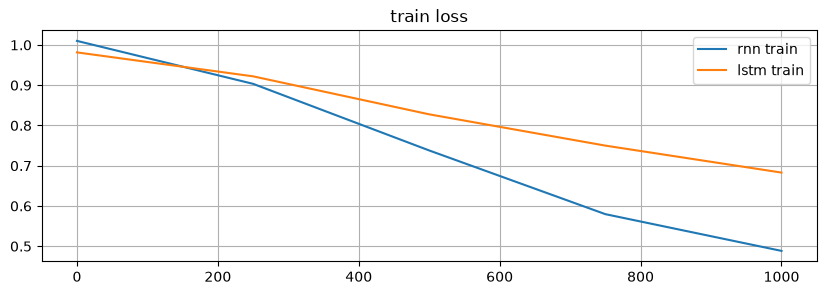

In [23]:
# both models fit the training data (train loss falls)...
plt.figure(figsize=(10, 3))
plt.plot([h[0] for h in hist_rnn], [h[1] for h in hist_rnn], label='rnn train')
plt.plot([h[0] for h in hist_lstm], [h[1] for h in hist_lstm], label='lstm train')
plt.grid(); plt.legend(); plt.title('train loss');

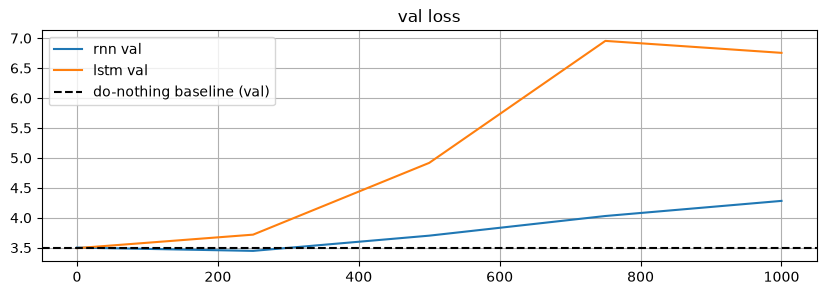

In [24]:
# ...but the val loss bottoms out at the "do nothing" baseline almost immediately and then RISES.
# the models are memorizing noise - this is what overfitting looks like in the wild.
plt.figure(figsize=(10, 3))
plt.plot([h[0] for h in hist_rnn], [h[2] for h in hist_rnn], label='rnn val')
plt.plot([h[0] for h in hist_lstm], [h[2] for h in hist_lstm], label='lstm val')
plt.axhline(baseline['val'].item(), color='k', linestyle='--', label='do-nothing baseline (val)')
plt.grid(); plt.legend(); plt.title('val loss');

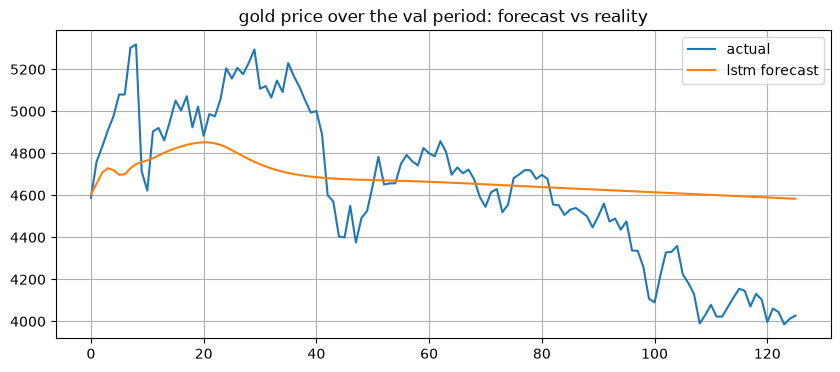

In [25]:
# the sampling moment: let the lstm forecast the entire val period, day by day,
# feeding each prediction back in as the next input, and integrate the predicted
# returns back into a price path
seed = train_data[-block_size:].view(1, block_size, 1) # the last 64 days of the train period
pred_rets = m_lstm.forecast(seed, len(val_data))       # 126 predicted returns

p_last_train = prices[n] # the last price the model has ever seen
pred_prices = p_last_train * torch.exp(torch.cumsum(pred_rets * std + mean, dim=0))
actual_prices = p_last_train * torch.exp(torch.cumsum(rets[n:], dim=0))

plt.figure(figsize=(10, 4))
plt.plot(actual_prices, label='actual')
plt.plot(pred_prices, label='lstm forecast')
plt.grid(); plt.legend(); plt.title('gold price over the val period: forecast vs reality');

In [26]:
# the forecast is a smooth, gently drifting curve next to a jagged reality:
# the model predicts only tiny returns (their std is far below the real thing),
# because tiny predictions are the mse-optimal answer to "tomorrow is unpredictable".
# the model has learned humility.
print(f'predicted daily move (std): {(pred_rets * std).std().item():.5f}')
print(f'actual daily move (std):    {rets[n:].std().item():.5f}')

predicted daily move (std): 0.00197
actual daily move (std):    0.02145


### Full finished code, for reference

Everything above, in one place.

4.513 K parameters
step 0: train loss 0.9816, val loss 3.4930
step 250: train loss 0.9221, val loss 3.7183
step 500: train loss 0.8277, val loss 4.9170
step 750: train loss 0.7500, val loss 6.9543
step 1000: train loss 0.6830, val loss 6.7545


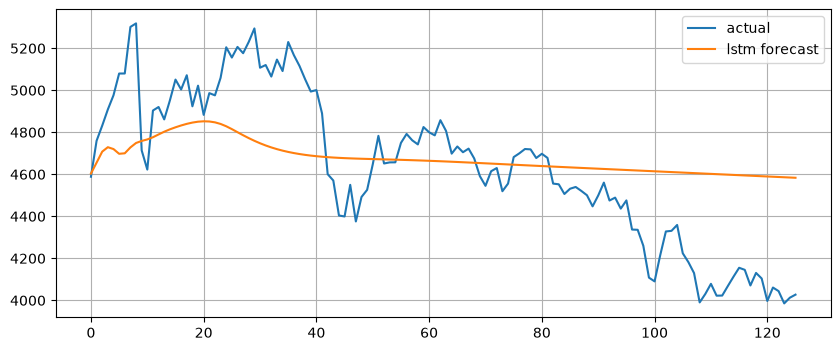

In [27]:
import csv
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# hyperparameters
block_size = 64      # how many days of history does the model get to see?
batch_size = 32      # how many independent windows will we process in parallel?
n_embd = 32          # how big is the hidden state?
max_iters = 1000
eval_interval = 250
eval_iters = 50
learning_rate = 1e-3
# ------------

torch.manual_seed(1337)

# data: daily gold prices -> normalized log returns, split by time (90/10)
with open('gold.csv') as f:
    rows = list(csv.DictReader(f))
prices = torch.tensor([float(r['Close']) for r in rows], dtype=torch.float32)
rets = torch.log(prices[1:]) - torch.log(prices[:-1])
n = int(0.9 * len(rets))
mean, std = rets[:n].mean(), rets[:n].std()          # train statistics only!
data = (rets - mean) / std
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix]).unsqueeze(-1)        # (B, T, 1)
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix]).unsqueeze(-1) # (B, T, 1)
    return x, y

class LSTMCell(nn.Module):
    """ a single LSTM timestep, from scratch """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        k = 1.0 / math.sqrt(hidden_size)
        self.weight_ih = nn.Parameter(torch.empty(4 * hidden_size, input_size).uniform_(-k, k))
        self.weight_hh = nn.Parameter(torch.empty(4 * hidden_size, hidden_size).uniform_(-k, k))
        self.bias_ih = nn.Parameter(torch.zeros(4 * hidden_size))
        self.bias_hh = nn.Parameter(torch.zeros(4 * hidden_size))

    def forward(self, x, hx):
        h, c = hx                                                    # both (B, H)
        gates = x @ self.weight_ih.T + self.bias_ih + h @ self.weight_hh.T + self.bias_hh # (B, 4H)
        i, f, g, o = gates.chunk(4, dim=1)                           # gate order: i, f, g, o
        i = torch.sigmoid(i)  # input gate:  how much of the candidate to write
        f = torch.sigmoid(f)  # forget gate: how much of the old memory to keep
        g = torch.tanh(g)     # candidate:   the new content itself
        o = torch.sigmoid(o)  # output gate: how much of the memory to expose
        c = f * c + i * g     # the cell state highway: updated by addition
        h = o * torch.tanh(c) # the hidden state: a gated readout of the cell
        return h, c

class LSTM(nn.Module):
    """ an LSTM unrolled over a sequence, from scratch """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = LSTMCell(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, hx=None):
        B, T, _ = x.shape
        if hx is None:
            h = x.new_zeros(B, self.hidden_size)
            c = x.new_zeros(B, self.hidden_size)
        else:
            h, c = hx
        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], (h, c))
            outs.append(h)
        return torch.stack(outs, dim=1), (h, c)   # (B, T, H), final state

class Forecaster(nn.Module):
    """ next-day return forecaster: recurrent core + linear head """

    def __init__(self, core, hidden_size):
        super().__init__()
        self.core = core
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x, targets=None):
        hs, _ = self.core(x)          # (B, T, 1) -> (B, T, H)
        logits = self.head(hs)        # (B, T, 1)
        loss = F.mse_loss(logits, targets) if targets is not None else None
        return logits, loss

    @torch.no_grad()
    def forecast(self, x, steps):
        # autoregressive rollout: predict the next return, append it, slide the window
        for _ in range(steps):
            logits, _ = self(x[:, -block_size:, :])
            x = torch.cat([x, logits[:, -1:, :]], dim=1)
        return x[0, -steps:, 0]

@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# train
model = Forecaster(LSTM(1, n_embd), n_embd)
print(sum(p.numel() for p in model.parameters()) / 1e3, 'K parameters')
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
for iter in range(max_iters + 1):
    if iter % eval_interval == 0 or iter == max_iters:
        losses = estimate_loss(model)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# forecast the val period, day by day, and integrate the returns back into prices
seed = train_data[-block_size:].view(1, block_size, 1)
pred_rets = model.forecast(seed, len(val_data))
pred_prices = prices[n] * torch.exp(torch.cumsum(pred_rets * std + mean, dim=0))
actual_prices = prices[n] * torch.exp(torch.cumsum(rets[n:], dim=0))
plt.figure(figsize=(10, 4))
plt.plot(actual_prices, label='actual')
plt.plot(pred_prices, label='lstm forecast')
plt.grid(); plt.legend();

### Notes:

- An LSTM is an RNN whose memory lives on an **additive highway** (the cell state `c`). Addition is what saves the gradient: we measured `||dL/d||` fall from ~8 to ~1e-17 over 50 steps in a vanilla RNN, while the cell-state path kept it alive to within ~2 orders of magnitude.
- The three gates (`i`, `f`, `o`) are soft, differentiable if-statements. Nothing about them is hand-coded - they are just `sigmoid` layers, trained end-to-end by backprop to decide what to write, keep, and expose.
- PyTorch's gate order is `(i, f, g, o)` - we matched it, which is what made the bit-exact check against `nn.LSTMCell`/`nn.LSTM` possible. In practice, just use `nn.LSTM`: it is the same math, but fused and much faster (our Python loop over time is the slow part).
- About the results: daily gold returns are essentially a random walk (even a linear probe on the last 10 returns cannot beat the "do nothing" baseline out-of-sample). Both models' val losses bottom out at that baseline and then rise as they memorize noise - textbook overfitting, and the honest outcome for this dataset. The point of the notebook was the machine, not the money.
- If you want a task where an LSTM *can* beat the baseline on this data: predict next-day volatility (squared returns) instead of returns. Volatility clusters (its lag-1 autocorrelation here is ~0.3), so there is real signal to learn.
- Natural next steps: stack layers (feed `h` of layer 1 as `x` of layer 2), try a GRU (2 gates, no separate cell state), or add "peephole" connections that let the gates see `c`.